In [1]:
import os
import sys

sys.path.append(os.path.join(os.path.dirname(os.getcwd())))
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "src"))

In [2]:
import mne
import mne_rsa

import pandas as pd
import numpy as np

from scipy.stats import spearmanr, zscore
from mne.stats import spatio_temporal_cluster_1samp_test, combine_adjacency

import pathlib
from src.word_level_hidden_states import word_level_hidden_state
from src.tokenizer_utils import load_tokenizer

import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science'])
plt.style.reload_library()
%matplotlib inline
%config InlineBackend.figure_format='retina'

from tqdm import tqdm

In [3]:
epochs_dict: dict[str, mne.Epochs] = {}

for file_name in os.listdir("../hf_datasets/eeg"):
    if file_name.endswith(".fif"):
        epochs = mne.read_epochs(os.path.join("../hf_datasets/eeg", file_name))
        epochs = epochs.apply_baseline((-0.4, 0.0))
        epochs._data *= -1
        epochs_dict[file_name.split("_")[0]] = epochs

Reading /Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/notebooks/../hf_datasets/eeg/p2_epochs.fif ...
    Found the data of interest:
        t =    -400.00 ...     800.00 ms
        0 CTF compensation matrices available
Not setting metadata
591 matching events found
No baseline correction applied
0 projection items activated
Applying baseline correction (mode: mean)


/var/folders/88/rz9pfrnd34q32tv5679ygvyh0000gn/T/ipykernel_47866/447796948.py:5: RuntimeWarning: This filename (../hf_datasets/eeg/p2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(os.path.join("../hf_datasets/eeg", file_name))


Reading /Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/notebooks/../hf_datasets/eeg/p12_epochs.fif ...
    Found the data of interest:
        t =    -400.00 ...     800.00 ms
        0 CTF compensation matrices available
Not setting metadata
591 matching events found
No baseline correction applied
0 projection items activated
Applying baseline correction (mode: mean)


/var/folders/88/rz9pfrnd34q32tv5679ygvyh0000gn/T/ipykernel_47866/447796948.py:5: RuntimeWarning: This filename (../hf_datasets/eeg/p12_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(os.path.join("../hf_datasets/eeg", file_name))


Reading /Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/notebooks/../hf_datasets/eeg/p17_epochs.fif ...
    Found the data of interest:
        t =    -400.00 ...     800.00 ms
        0 CTF compensation matrices available
Not setting metadata
596 matching events found
No baseline correction applied
0 projection items activated
Applying baseline correction (mode: mean)


...

Reading /Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/notebooks/../hf_datasets/eeg/p1_epochs.fif ...
    Found the data of interest:
        t =    -400.00 ...     800.00 ms
        0 CTF compensation matrices available


/var/folders/88/rz9pfrnd34q32tv5679ygvyh0000gn/T/ipykernel_47866/447796948.py:5: RuntimeWarning: This filename (../hf_datasets/eeg/p1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(os.path.join("../hf_datasets/eeg", file_name))


Not setting metadata
600 matching events found
No baseline correction applied
0 projection items activated
Applying baseline correction (mode: mean)
Reading /Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/notebooks/../hf_datasets/eeg/p11_epochs.fif ...
    Found the data of interest:
        t =    -400.00 ...     800.00 ms
        0 CTF compensation matrices available


/var/folders/88/rz9pfrnd34q32tv5679ygvyh0000gn/T/ipykernel_47866/447796948.py:5: RuntimeWarning: This filename (../hf_datasets/eeg/p11_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(os.path.join("../hf_datasets/eeg", file_name))


Not setting metadata
600 matching events found
No baseline correction applied
0 projection items activated
Applying baseline correction (mode: mean)


Подсчет событий для каждого субъекта

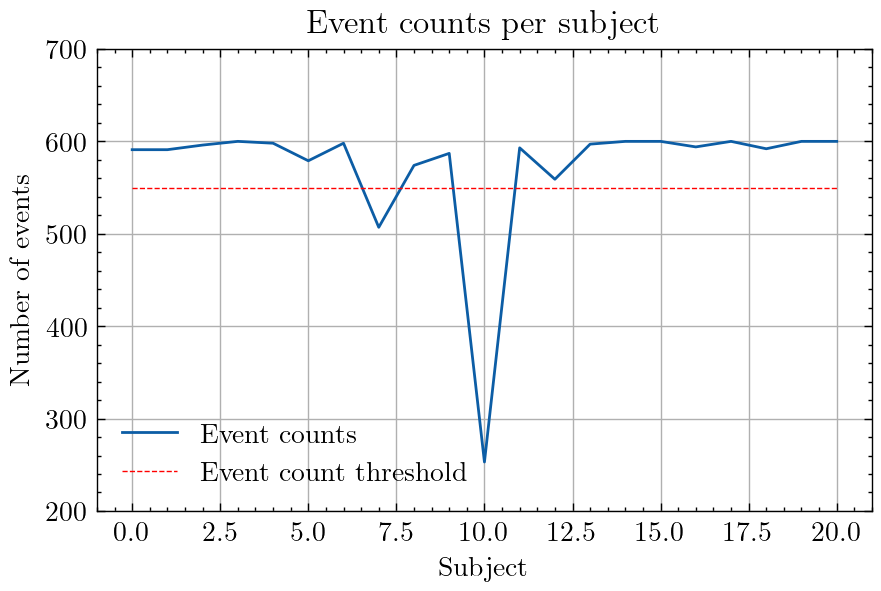

In [4]:
event_counts = []
for epochs in epochs_dict.values():
    event_counts.append(len(epochs))

plt.figure(figsize=[5, 3])
plt.plot(event_counts, label="Event counts")
plt.grid(True)
plt.title("Event counts per subject")
plt.ylabel("Number of events")
plt.xlabel("Subject")
plt.ylim((200, 700))
plt.hlines(550, xmin=0, xmax=20, linestyles="dashed", linewidth=0.5, colors="red", label="Event count threshold")
plt.legend()
plt.show()

In [5]:
threshold = 500
filtered_epoch_dict: dict[str, mne.Epochs] = {}
for k, epochs in epochs_dict.items():
    if len(epochs) > threshold:
        filtered_epoch_dict[k] = epochs

print(f"Отобрано {len(filtered_epoch_dict)} испытуемых")

erps_dict: dict[str, list[mne.Evoked]] = {}
for k, epochs in filtered_epoch_dict.items():
    erps_dict[k] = epochs.average(by_event_type=True)

print("Усреднение по событиям завершено")

conditions = [averaged.comment for averaged in erps_dict["p1"]]
print(f"Условия {conditions}")

Отобрано 20 испытуемых
Усреднение по событиям завершено
Условия ['Stimulus/S  1_1', 'Stimulus/S  1_2', 'Stimulus/S  1_3', 'Stimulus/S  2_1', 'Stimulus/S  2_2', 'Stimulus/S  2_3', 'Stimulus/S  3_1', 'Stimulus/S  3_2', 'Stimulus/S  3_3', 'Stimulus/S  4_1', 'Stimulus/S  4_2', 'Stimulus/S  4_3']


In [6]:
def make_windows(times, win_len=0.02, win_step=0.01):
    tmin, tmax = times[0], times[-1]
    starts = np.arange(tmin, tmax - win_len, win_step)
    windows = [(s, s + win_len) for s in starts]
    return windows

def compute_eeg_rdms_mne_rsa(
    erps_dict: dict[str, list[mne.Evoked]],
    win_len: float = 0.02,
    win_step: float = 0.01,
    picks: list[str] | None = None,
):

    subj_ids = list(erps_dict.keys())

    times = erps_dict[subj_ids[0]][0].times
    windows = make_windows(times, win_len, win_step)
    win_times = np.array(windows)

    rdms = []

    for subj in subj_ids:
        evokeds = erps_dict[subj]

        if picks is not None:
            evokeds = [e.copy().pick(picks) for e in evokeds]

        # stack: (conditions, channels, time)
        data = np.stack([e.data for e in evokeds], axis=0)

        subj_rdms = []

        for tmin, tmax in windows:
            # crop window
            idx = np.where((times >= tmin) & (times <= tmax))[0]
            Xw = data[:, :, idx].mean(axis=2)  # (12, channels)

            # z-score по условиям (ось 0)
            Xw = (Xw - Xw.mean(axis=0)) / Xw.std(axis=0)

            # RDM через mne_rsa
            rdm = mne_rsa.compute_rdm(
                Xw,
                metric="correlation",   # 1 - corr
            )
            subj_rdms.append(rdm)
        rdms.append(subj_rdms)
    rdms = np.asarray(rdms)
    return rdms, win_times, subj_ids


rdms_eeg, win_times, subj_ids = compute_eeg_rdms_mne_rsa(erps_dict)


In [7]:
rdms_eeg.shape

(20, 119, 66)

Загрузка описания событий

In [8]:
events_description_df = pd.read_csv("/Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/hf_datasets/events_description.csv")

def map_congruence_conditions(condition: str):
    condition = condition.lower()
    if condition == "congruent":
        return "normal"
    elif condition == "semantically incongruent":
        return "semantics"
    elif condition == "grammatically incongruent":
        return "grammar"
    elif condition == "semantically-grammatically incongruent":
        return "semantics_grammar"
    else:
        raise ValueError("Unknown condition")

events_description_df["target"] = events_description_df["congruence_condition"].apply(map_congruence_conditions)
events_description_df["sentence_structure"] = events_description_df["sentence_structure"].apply(lambda x: x.replace("Adjective", "Adj").replace("Genitive", "Gen"))

events_description_df = events_description_df[["name", "sentence_structure", "target"]]
events_description_df = events_description_df.rename(columns={"sentence_structure": "structure", "name": "event_name"})

events_description_df

,event_name,structure,target
0,Stimulus/S 1_1,Subject - Verb - Object,normal
1,Stimulus/S 1_2,Subject - Verb - Adj - Object,normal
2,Stimulus/S 1_3,Subject - Verb - Object - Gen,normal
3,Stimulus/S 2_1,Subject - Verb - Object,semantics
4,Stimulus/S 2_2,Subject - Verb - Adj - Object,semantics
5,Stimulus/S 2_3,Subject - Verb - Object - Gen,semantics
6,Stimulus/S 3_1,Subject - Verb - Object,grammar
7,Stimulus/S 3_2,Subject - Verb - Adj - Object,grammar
8,Stimulus/S 3_3,Subject - Verb - Object - Gen,grammar
9,Stimulus/S 4_1,Subject - Verb - Object,semantics_grammar


In [12]:

model_hidden_state_folders = [
    ("ai-sage/GigaChat3-10B-A1.8B-base", "/Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/src/results/ai-sage_GigaChat3-10B-A1.8B-base")
]

model_rdm_dict: dict[str, list] = {}
stimuli_df = pd.read_csv("../hf_datasets/stimuli.csv")
stimuli_df = stimuli_df.merge(events_description_df, how="left", on=["structure", "target"])

for model, folder in model_hidden_state_folders:

    model_tokenizer = load_tokenizer(model)

    results_df = pd.read_csv(folder + "/results.csv")
    results_df = results_df.merge(stimuli_df, how="left", left_on="sentence", right_on="sentence")

    events_names_and_hidden_paths_df = results_df[["event_name", "hidden_states_path", "sentence", "position"]]

    unique_event_names = events_names_and_hidden_paths_df["event_name"].unique()

    layer_event_dict: dict[int, dict[str, list]] = {}

    for event_name in unique_event_names:
        event_rows = events_names_and_hidden_paths_df[events_names_and_hidden_paths_df["event_name"] == event_name]
        event_word_states = [

        ]
        for i, row in event_rows.iterrows():

            hidden_states_path = row["hidden_states_path"]
            relative_hidden_state_path = pathlib.Path(hidden_states_path)
            absolute_hidden_state_path = pathlib.Path(folder).parent.parent / relative_hidden_state_path
            loaded_hidden_states = np.load(absolute_hidden_state_path)

            target_word_hidden_state, _ = word_level_hidden_state(
                sentence_hidden_states=loaded_hidden_states,
                tokenizer=model_tokenizer,
                sentence=row["sentence"],
                word_position=int(row["position"])
            )

            for layer in range(len(target_word_hidden_state)):
                if layer not in layer_event_dict:
                    layer_event_dict[layer] = {}
                if event_name not in layer_event_dict[layer]:
                    layer_event_dict[layer][event_name] = []
                layer_event_dict[layer][event_name].append(target_word_hidden_state[layer])

    # Усреднение скрытых состояний для каждого типа событий по слоям
    for layer_num, event_hidden_dict in layer_event_dict.items():
        _event_hidden_dict = event_hidden_dict.copy()
        for event_name, hidden_states in _event_hidden_dict.items():
            _event_hidden_dict[event_name] = np.stack(hidden_states).mean(axis=0)
        layer_event_dict[layer_num] = _event_hidden_dict


    models_rdm_folder = pathlib.Path("./model_rdm")
    models_rdm_folder.mkdir(parents=True, exist_ok=True)

    model_rdm_folder = models_rdm_folder / model.replace("/", "-")
    model_rdm_folder.mkdir(parents=True, exist_ok=True)

    # Составление матриц расхождения
    for layer_num, event_hidden_dict in layer_event_dict.items():

        model_mean_hidden_list = []
        for condition in conditions:
            model_mean_hidden_list.append(event_hidden_dict[condition])

        X = np.stack(model_mean_hidden_list)   # (12, d)

        # z-score по условиям, отдельно для каждого нейрона
        X = (X - X.mean(axis=0)) / X.std(axis=0)

        layer_rdm = mne_rsa.compute_rdm(
            data=X,
            metric="correlation",
        )

        layer_rdm_path = model_rdm_folder / f"layer_{layer_num}.npy"

        np.save(layer_rdm_path, layer_rdm)

    rdms_llm = np.stack([np.load(f) for f in model_rdm_folder.iterdir()])

2025-12-20 23:17:17 INFO     src.tokenizer_utils: Tokenizer adds prefix space


Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading service token
Skipp heading servic

In [13]:
def rsa_eeg_llm(
    rdms_eeg: np.ndarray,   # (subjects, windows, n_pairs)
    rdms_llm: np.ndarray,   # (layers, n_pairs)
) -> np.ndarray:
    if rdms_eeg.ndim != 3:
        raise ValueError(
            f"rdms_eeg must be 3D (S, W, n_pairs), got shape {rdms_eeg.shape}"
        )

    if rdms_llm.ndim != 2:
        raise ValueError(
            f"rdms_llm must be 2D (L, n_pairs), got shape {rdms_llm.shape}"
        )

    S, W, n_pairs_eeg = rdms_eeg.shape
    L, n_pairs_llm = rdms_llm.shape

    if n_pairs_eeg != n_pairs_llm:
        raise ValueError(
            "EEG and LLM RDMs have different number of pairs: "
            f"{n_pairs_eeg} (EEG) vs {n_pairs_llm} (LLM)"
        )

    n_cond = int((1 + np.sqrt(1 + 8 * n_pairs_eeg)) / 2)
    if n_cond * (n_cond - 1) // 2 != n_pairs_eeg:
        raise ValueError(
            f"n_pairs={n_pairs_eeg} is not a valid condensed RDM size"
        )

    if not np.isfinite(rdms_eeg).all():
        raise ValueError("rdms_eeg contains NaN or inf")

    if not np.isfinite(rdms_llm).all():
        raise ValueError("rdms_llm contains NaN or inf")

    rsa = np.zeros((S, W, L), dtype=np.float64)

    for s in range(S):
        for w in range(W):
            eeg_vec = rdms_eeg[s, w]

            for l in range(L):
                rho, _ = spearmanr(eeg_vec, rdms_llm[l])
                rsa[s, w, l] = rho

    return rsa



rsa = rsa_eeg_llm(rdms_eeg, rdms_llm)

Перестановочный тест

In [14]:


S, W, L = rsa.shape
adjacency = combine_adjacency(W, L)

T_obs, clusters, cluster_p_values, H0 = spatio_temporal_cluster_1samp_test(
    rsa,
    adjacency=adjacency,
    n_permutations=500,
    threshold=None,     # автоматически t-threshold
    tail=1,             # RSA > 0
    out_type="mask",
    verbose=True,
)


Using a threshold of 1.729133
stat_fun(H1): min=-2.4740173682322335 max=9.220303140669328
Running initial clustering …
Found 36 clusters


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  0%|          | Permuting : 0/499 [00:00<?,       ?it/s]

In [15]:
alpha = 0.05
signif_mask = np.zeros((W, L), dtype=bool)

for clu_mask, pval in zip(clusters, cluster_p_values):
    if pval < alpha:
        signif_mask |= clu_mask

print("Significant clusters:", np.sum(cluster_p_values < alpha))

Significant clusters: 1


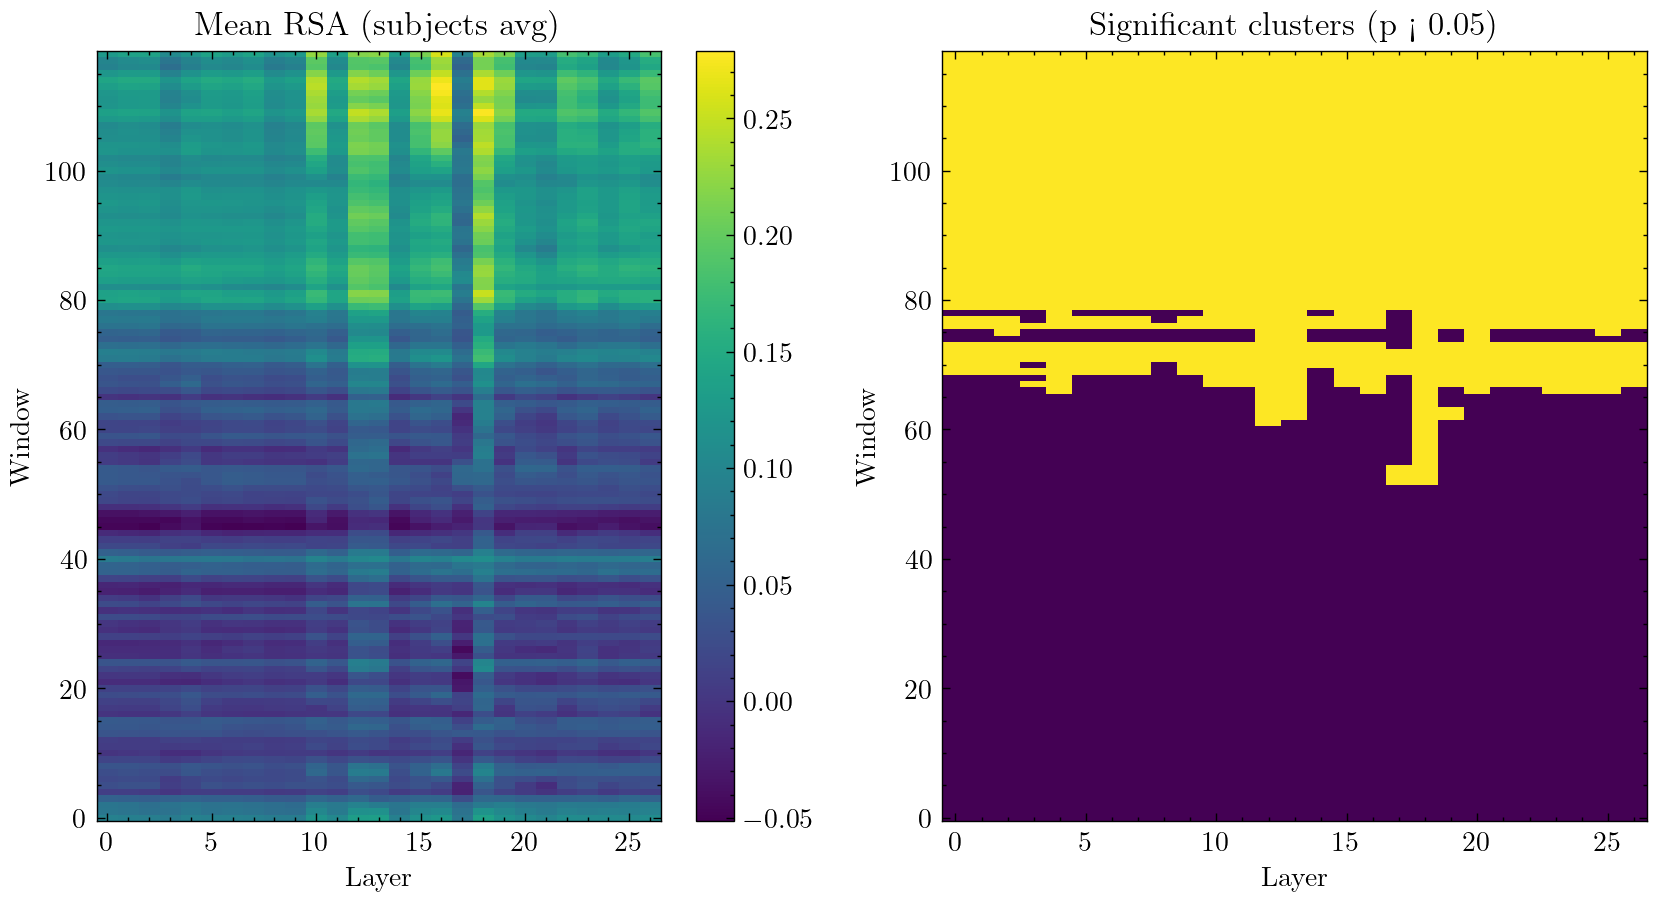

In [16]:

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs = axs.flatten()



im = axs[0].imshow(rsa.mean(axis=0), aspect="auto", origin="lower")
axs[0].set_title("Mean RSA (subjects avg)")
axs[0].set_xlabel("Layer")
axs[0].set_ylabel("Window")
fig.colorbar(im, ax=axs[0], orientation="vertical", pad=0.05)

axs[1].imshow(signif_mask, aspect="auto", origin="lower")
axs[1].set_title("Significant clusters (p < 0.05)")
axs[1].set_xlabel("Layer")
axs[1].set_ylabel("Window")

plt.show()
